In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Patch
import matplotlib

matplotlib.rcParams.update({'font.size': 25})

## Viz by property - categoricals

In [ ]:
df = pd.read_csv("reports/table_report_nil_f1.csv")

In [ ]:
# preprocess df
df['Model'] = pd.Categorical(df['Model'], ['Boyer-M', 'Mixtral', 'Phi-3', 'Gemma', 'LLAMA', 'Qwen', 'GPT-4o'])
df.loc[df.Retriever == "-", "Retriever"] = "Zero shot"
df = df.sort_values(["Model", "Retriever"])
df.columns = ["Model", "Retriever", "CoC", "DoB", "Family", "Given", "Occ.", "Gender"]

# assign one color to each retriever
retrievers = df.Retriever.unique()
retriever_color = {
    r: colormaps["tab20"](i / (len(retrievers) + 1))
    for i, r in enumerate(retrievers)
}

width = 1
properties = df.columns[3:]
fig, axs = plt.subplots(len(properties), 1, figsize=(21, 14))

for property_i, prop_name in enumerate(properties):
    ax = axs[property_i]
    xlabel_x = []
    offset = 0
    prop_df = df[["Model", "Retriever", prop_name]]
    prop_best = tuple(prop_df.iloc[prop_df[prop_name].argmax()][:2])

    for model_i, (model_name, model_df) in enumerate(prop_df.groupby("Model")):
        xlabel_x.append(offset + len(model_df) // 2)
        for result_i, (_, (_, retriever_name, val)) in enumerate(model_df.iterrows()):
            if (model_name, retriever_name) == prop_best:
                hatch = "*"
            elif result_i == model_df[prop_name].argmax():
                hatch = "\\"
            else:
                hatch = ""

            ax.bar(
                x=offset, 
                height=val,
                width=width,
                facecolor=retriever_color[retriever_name],
                hatch=hatch,
                label=retriever_name,
                hatch_linewidth=3 if hatch == "\\" else 1, 
            )
            offset += width

        offset += width
    
    ax.set_xticks(ticks=xlabel_x, labels=prop_df.Model.unique())
    ax.set_ylim(0, 1)
    
    ax.yaxis.tick_right()
    ax.set_yticks(ticks=[0, 1])
    ax.set_ylabel(prop_name)

fig.legend(
    loc="upper center",
    handles=[
        Patch(facecolor=color, label=label)
        for label, color in retriever_color.items()
    ],
    bbox_to_anchor=(0.5, 1.03),
    ncols=len(retriever_color)
)

fig.tight_layout()

In [ ]:
fig.savefig('NIL-KG_properties_f1_bigger.png', dpi=900, bbox_inches = "tight")

## Viz by property - ordinal

In [101]:
df = pd.read_csv("granular_analyses/DoB/reports/combined_granular_report_qid.csv")

/tmp/ipykernel_19208/918753306.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_i, (model_name, model_df) in enumerate(prop_df.groupby("Model")):
/tmp/ipykernel_19208/918753306.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_i, (model_name, model_df) in enumerate(prop_df.groupby("Model")):
/tmp/ipykernel_19208/918753306.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_i, (model_

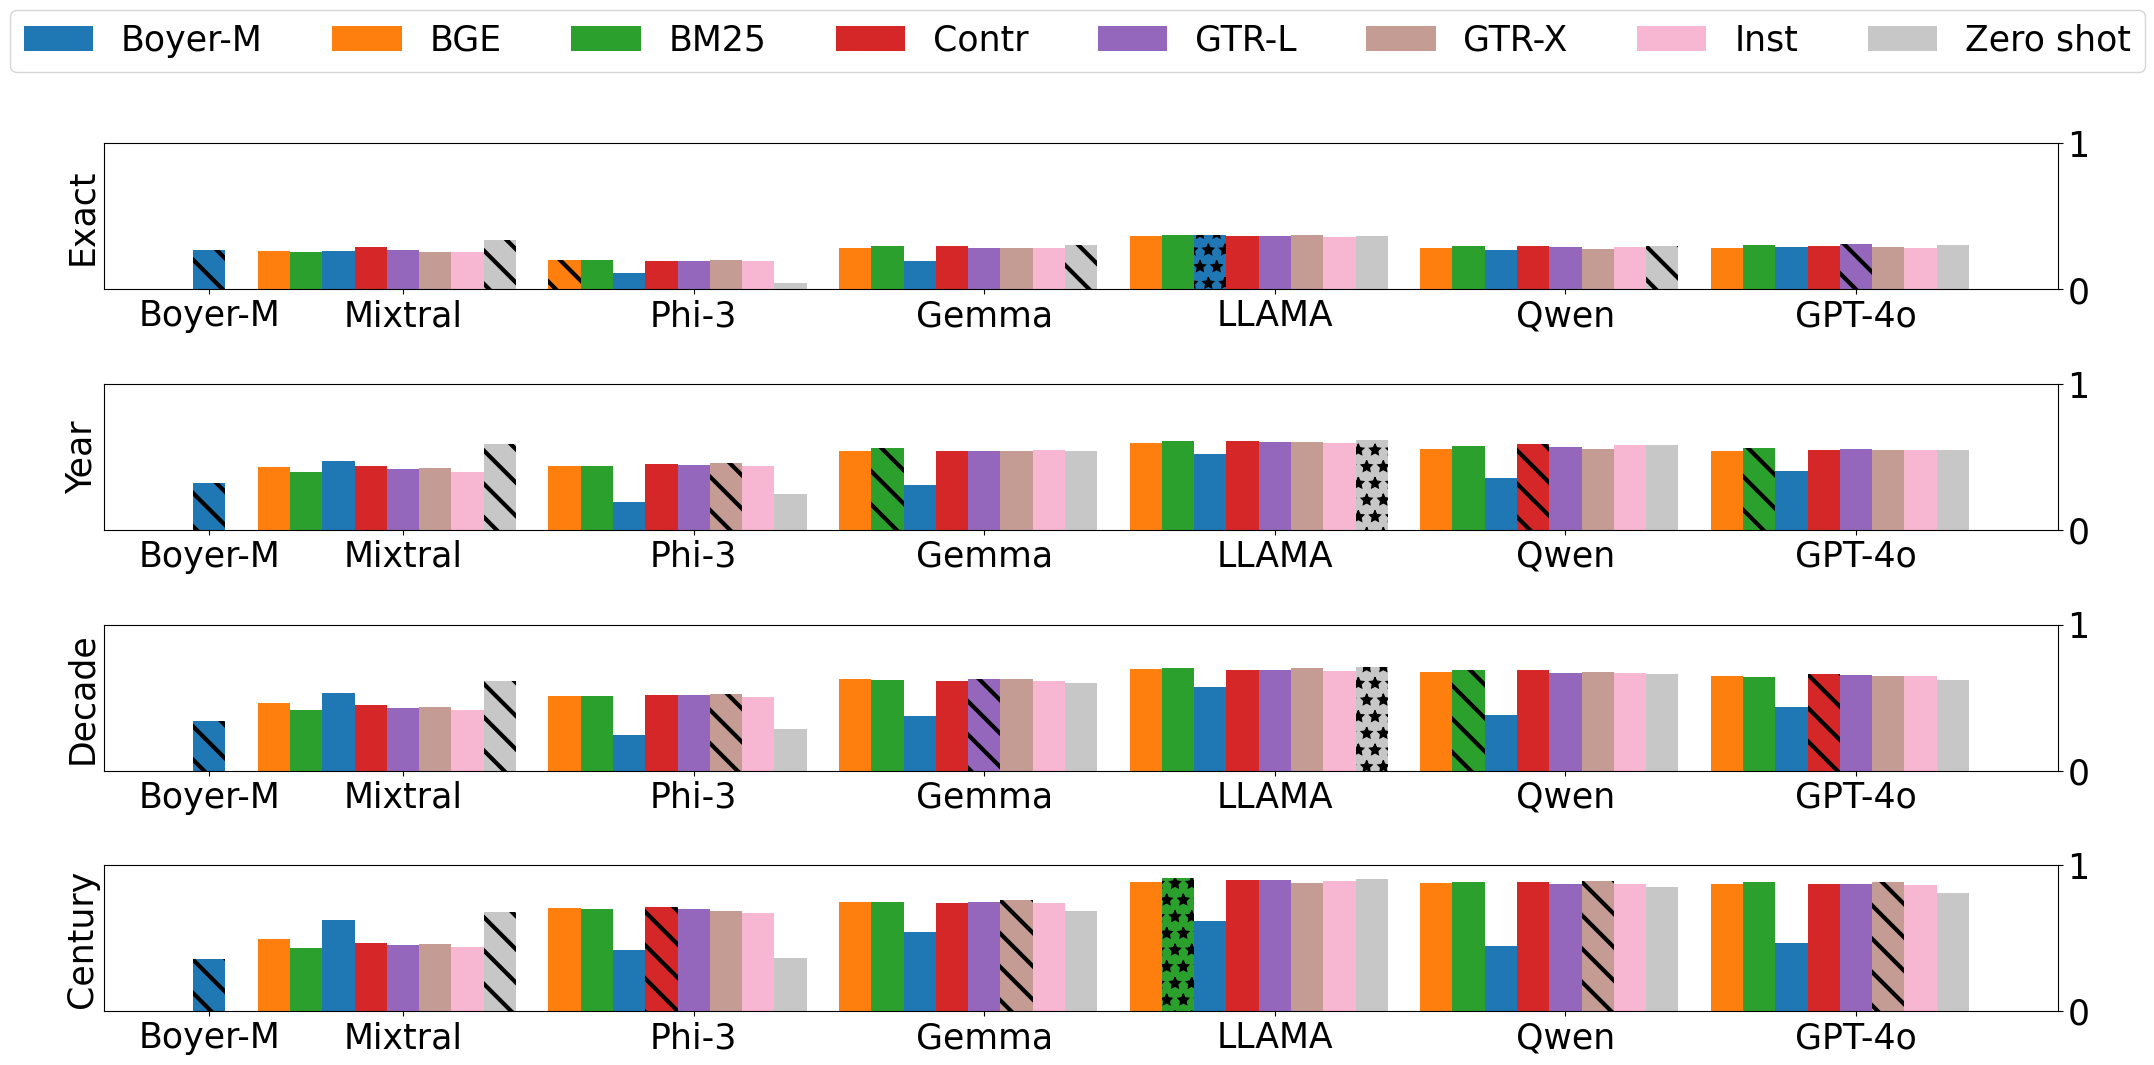

In [102]:
# preprocess df
df = df[['Model', 'Retriever', 'Exact_F1', 'Year_F1', 'Decade_F1', 'Century_F1']]
df.loc[df.Retriever == "-", "Retriever"] = "Zero shot"
df['Model'] = pd.Categorical(df['Model'], ['Boyer-M', 'Mixtral', 'Phi-3', 'Gemma', 'LLAMA', 'Qwen', 'GPT-4o'])
df = df.sort_values(["Model", "Retriever"])
df.columns = ['Model', 'Retriever', 'Exact', 'Year', 'Decade', 'Century']

# assign one color to each retriever
retrievers = df.Retriever.unique()
retriever_color = {
    r: colormaps["tab20"](i / (len(retrievers) + 1))
    for i, r in enumerate(retrievers)
}

width = 1
properties = df.columns[2:]
fig, axs = plt.subplots(len(properties), 1, figsize=(21, 10))

for property_i, prop_name in enumerate(properties):
    ax = axs[property_i]
    xlabel_x = []
    offset = 0
    prop_df = df[["Model", "Retriever", prop_name]]
    prop_best = tuple(prop_df.iloc[prop_df[prop_name].argmax()][:2])

    for model_i, (model_name, model_df) in enumerate(prop_df.groupby("Model")):
        xlabel_x.append(offset + len(model_df) // 2)
        for result_i, (_, (_, retriever_name, val)) in enumerate(model_df.iterrows()):
            if (model_name, retriever_name) == prop_best:
                hatch = "*"
            elif result_i == model_df[prop_name].argmax():
                hatch = "\\"
            else:
                hatch = ""

            ax.bar(
                x=offset, 
                height=val,
                width=width,
                facecolor=retriever_color[retriever_name],
                hatch=hatch,
                label=retriever_name,
                hatch_linewidth=3 if hatch == "\\" else 1, 
            )
            offset += width

        offset += width
    
    ax.set_xticks(ticks=xlabel_x, labels=prop_df.Model.unique())
    ax.set_ylim(0, 1)
    
    ax.yaxis.tick_right()
    ax.set_yticks(ticks=[0, 1])
    ax.set_ylabel(prop_name)

fig.legend(
    loc="upper center",
    handles=[
        Patch(facecolor=color, label=label)
        for label, color in retriever_color.items()
    ],
    bbox_to_anchor=(0.5, 1.1),
    ncols=len(retriever_color)
)

fig.tight_layout()

In [103]:
fig.savefig('QID-KG_DoB_granular_f1.png', dpi=900, bbox_inches = "tight")

## Viz for occupation

In [116]:
df = pd.read_csv("granular_analyses/occupation/reports/summary/nil_occupation_multiclass_report.csv")

/tmp/ipykernel_19208/2054715530.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_i, (model_name, model_df) in enumerate(prop_df.groupby("Model")):
/tmp/ipykernel_19208/2054715530.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_i, (model_name, model_df) in enumerate(prop_df.groupby("Model")):
/tmp/ipykernel_19208/2054715530.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_i, (mod

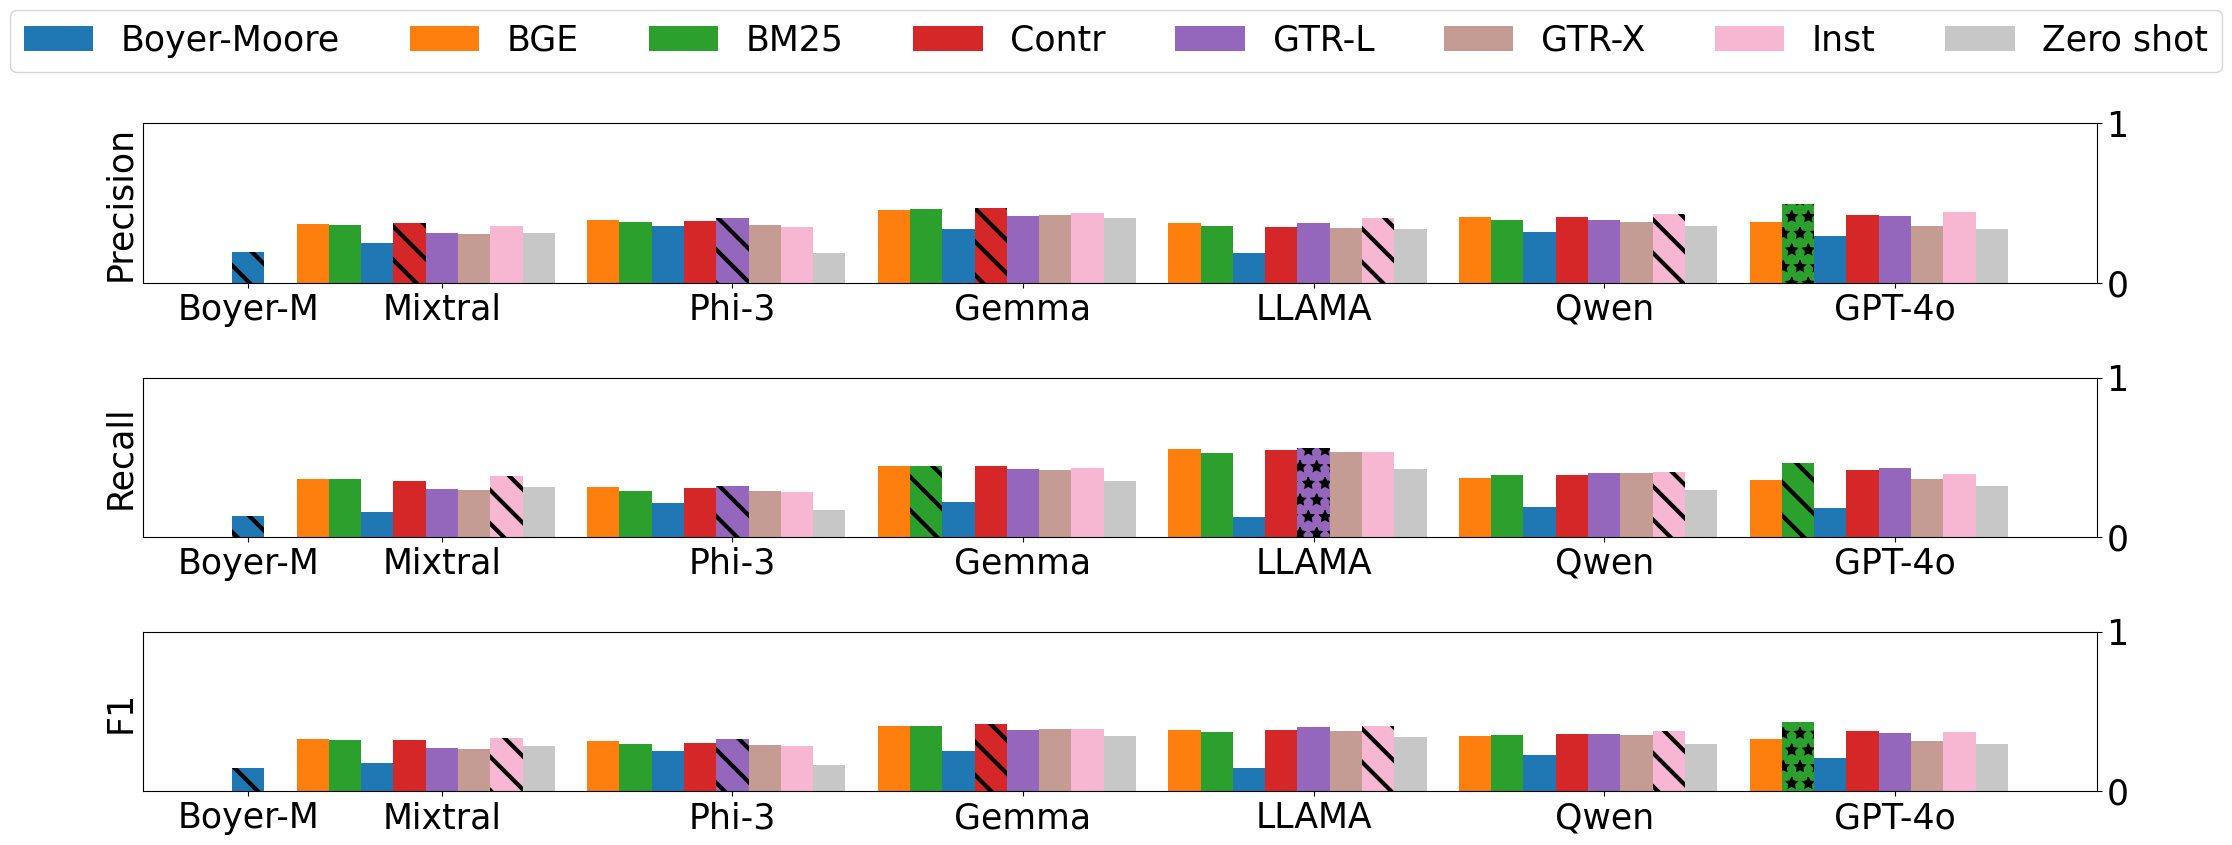

In [117]:
# preprocess df
df = df[['llm', 'retriever', 'precision_mean', 'recall_mean', 'f1_mean']]
df.loc[df.llm == "Majority Voting", "llm"] = "Boyer-M"
df.columns = ['Model', 'Retriever', 'Precision', 'Recall', 'F1']
df.loc[df.Retriever == "-", "Retriever"] = "Zero shot"
df['Model'] = pd.Categorical(df['Model'], ['Boyer-M', 'Mixtral', 'Phi-3', 'Gemma', 'LLAMA', 'Qwen', 'GPT-4o'])
df = df.sort_values(["Model", "Retriever"])

# assign one color to each retriever
retrievers = df.Retriever.unique()
retriever_color = {
    r: colormaps["tab20"](i / (len(retrievers) + 1))
    for i, r in enumerate(retrievers)
}

width = 1
properties = df.columns[2:]
fig, axs = plt.subplots(len(properties), 1, figsize=(21, 8))

for property_i, prop_name in enumerate(properties):
    ax = axs[property_i]
    xlabel_x = []
    offset = 0
    prop_df = df[["Model", "Retriever", prop_name]]
    prop_best = tuple(prop_df.iloc[prop_df[prop_name].argmax()][:2])

    for model_i, (model_name, model_df) in enumerate(prop_df.groupby("Model")):
        xlabel_x.append(offset + len(model_df) // 2)
        for result_i, (_, (_, retriever_name, val)) in enumerate(model_df.iterrows()):
            if (model_name, retriever_name) == prop_best:
                hatch = "*"
            elif result_i == model_df[prop_name].argmax():
                hatch = "\\"
            else:
                hatch = ""

            ax.bar(
                x=offset, 
                height=val,
                width=width,
                facecolor=retriever_color[retriever_name],
                hatch=hatch,
                label=retriever_name,
                hatch_linewidth=3 if hatch == "\\" else 1, 
            )
            offset += width

        offset += width
    
    ax.set_xticks(ticks=xlabel_x, labels=prop_df.Model.unique())
    ax.set_ylim(0, 1)
    
    ax.yaxis.tick_right()
    ax.set_yticks(ticks=[0, 1])
    ax.set_ylabel(prop_name)

fig.legend(
    loc="upper center",
    handles=[
        Patch(facecolor=color, label=label)
        for label, color in retriever_color.items()
    ],
    bbox_to_anchor=(0.5, 1.1),
    ncols=len(retriever_color)
)

fig.tight_layout()

In [118]:
fig.savefig('NIL-KG_Occ_granular.png', dpi=900, bbox_inches = "tight")